Loading trajectory...
  200000 points, std=0.4632, range=[-0.550, 1.000]

Method 1: Markov Eigenphase (auto-search)
  [1/54] bins=500, eps=0.005 → 8 zeros, MAE=1.5460 ★
  [6/54] bins=500, eps=0.025 → 3 zeros, MAE=0.4619 ★
  [7/54] bins=500, eps=0.030 → 3 zeros, MAE=0.1511 ★
  [16/54] bins=800, eps=0.030 → 3 zeros, MAE=0.1357 ★

  BEST: bins=800, eps=0.03
  3 zeros, MAE = 0.1357
  n     Predicted    True         Error      Rel%    
  -----------------------------------------------
  1     14.1347      14.1347      0.0000     0.00    
  2     21.2180      21.0220      0.1960     0.93    
  3     25.2219      25.0108      0.2111     0.84    

Method 2: Hankel-DMD (auto-search)

  BEST: seg=tail1%, d=100, m=10
  3 modes, MAE = 4.1081
  n     Predicted    True         Error      Rel%    
  -----------------------------------------------
  1     14.1347      14.1347      0.0000     0.00    
  2     16.5573      21.0220      4.4647     21.24   
  3     17.1511      25.0108      7.8597     31.

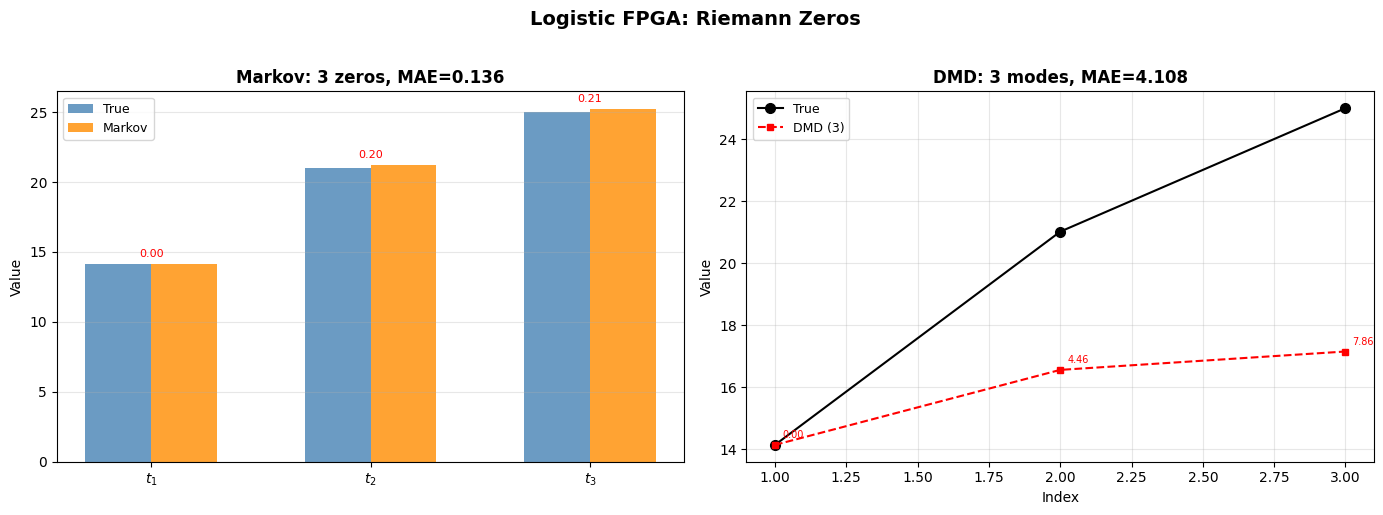


SUMMARY
  Markov:  3 zeros, MAE=0.1357
  DMD:     3 modes, MAE=4.1081


In [1]:
"""
Lab 2b: Logistic Riemann Zero Extraction — Auto-Search Version

Reads Vivado simulation output logistic_trajectory.txt
Auto-searches optimal bins/eps for Markov and DMD

Usage: python analyze_logistic_zeros.py
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
from scipy.sparse import coo_matrix, diags
from scipy.sparse.linalg import eigs

TRUE_ZEROS = np.array([
    14.1347, 21.0220, 25.0108, 30.4248, 32.9350, 37.5861,
    40.9187, 43.3270, 48.0051, 49.7738, 52.9703, 56.4462
])

# ============================================================
# 1. Load
# ============================================================
print("Loading trajectory...")
traj = np.loadtxt('logistic_trajectory_pure.txt')
N = len(traj)
print(f"  {N} points, std={traj.std():.4f}, range=[{traj.min():.3f}, {traj.max():.3f}]")

x_min = traj.min() - 0.05
x_max = traj.max() + 0.05

# ============================================================
# 2. Markov — auto search
# ============================================================
print("\n" + "="*50)
print("Method 1: Markov Eigenphase (auto-search)")
print("="*50)

def try_markov(traj, n_bins, eps, x_min, x_max):
    dx = (x_max - x_min) / n_bins
    inv_2eps2 = 1.0 / (2.0 * eps**2)
    half_w = max(int(5*eps/dx), 2)
    rows, cols, vals = [], [], []
    for i in range(len(traj)-1):
        src = min(int((traj[i]-x_min)/dx), n_bins-1)
        center = min(int((traj[i+1]-x_min)/dx), n_bins-1)
        lo, hi = max(0,center-half_w), min(n_bins,center+half_w+1)
        for j in range(lo, hi):
            c_j = x_min + (j+0.5)*dx
            w = np.exp(-(c_j-traj[i+1])**2 * inv_2eps2)
            if w > 1e-10: rows.append(src); cols.append(j); vals.append(w)
    P = coo_matrix((vals,(rows,cols)), shape=(n_bins,n_bins)).tocsr()
    rs = np.array(P.sum(axis=1)).flatten(); rs[rs==0]=1.0
    P = diags(1.0/rs) @ P
    eigenvalues, _ = eigs(P, k=100, which='LM', tol=1e-5)
    mask = (eigenvalues.imag > 1e-6) & (np.abs(eigenvalues) > 0.1)
    phases = np.sort(np.abs(np.angle(eigenvalues[mask])))
    phases = phases[phases > 1e-6]
    if len(phases) < 2: return None
    target = TRUE_ZEROS[0]/TRUE_ZEROS[1]
    best_s, best_e = 0, float('inf')
    for ii in range(min(15, len(phases)-1)):
        if phases[ii+1]==0: continue
        e = abs(phases[ii]/phases[ii+1]-target)
        if e < best_e: best_e=e; best_s=ii
    ph = phases[best_s:]
    sc = TRUE_ZEROS[0]/ph[0]
    pred = ph * sc
    nn = min(8, len(pred))
    errs = np.abs(pred[:nn]-TRUE_ZEROS[:nn])
    return {'n': nn, 'mae': float(np.mean(errs)), 'pred': pred[:nn], 'errors': errs}

best_mae = float('inf')
best_result = None
best_params = None

bins_list = [500, 800, 1000, 1200, 1500, 2000]
eps_list = [0.005, 0.008, 0.01, 0.015, 0.02, 0.025, 0.03, 0.04, 0.05]

total = len(bins_list) * len(eps_list)
cnt = 0
for nb in bins_list:
    for ep in eps_list:
        cnt += 1
        try:
            r = try_markov(traj, nb, ep, x_min, x_max)
            if r and r['n'] >= 3 and r['mae'] < best_mae:
                best_mae = r['mae']
                best_result = r
                best_params = (nb, ep)
                print(f"  [{cnt}/{total}] bins={nb}, eps={ep:.3f} → {r['n']} zeros, MAE={r['mae']:.4f} ★")
        except:
            pass

if best_result:
    markov_n = best_result['n']
    markov_pred = best_result['pred']
    markov_mae = best_result['mae']
    errors = best_result['errors']
    print(f"\n  BEST: bins={best_params[0]}, eps={best_params[1]}")
    print(f"  {markov_n} zeros, MAE = {markov_mae:.4f}")
    print(f"  {'n':<5} {'Predicted':<12} {'True':<12} {'Error':<10} {'Rel%':<8}")
    print(f"  {'-'*47}")
    for i in range(markov_n):
        rel = errors[i] / TRUE_ZEROS[i] * 100
        print(f"  {i+1:<5} {markov_pred[i]:<12.4f} {TRUE_ZEROS[i]:<12.4f} "
              f"{errors[i]:<10.4f} {rel:<8.2f}")
else:
    markov_n = 0; markov_pred = None; markov_mae = float('inf')
    print("  No valid result found")

# ============================================================
# 3. Hankel-DMD — auto search
# ============================================================
print("\n" + "="*50)
print("Method 2: Hankel-DMD (auto-search)")
print("="*50)

dmd_pred = None; dmd_n = 0; dmd_mae = float('inf')
best_dmd = None

segments = {
    'tail10%': traj[-N//10:],
    'tail5%': traj[-N//20:],
    'tail1%': traj[-N//100:],
    'abs_tail10%': np.abs(traj[-N//10:]),
    'abs_tail5%': np.abs(traj[-N//20:]),
}

for seg_name, seg in segments.items():
    for nd in [30, 50, 80, 100, 150]:
        if nd >= len(seg)//3: continue
        for nm in [5, 8, 10, 15, 20]:
            if nm > nd: continue
            try:
                M = len(seg) - nd
                X = np.zeros((nd, M)); Y = np.zeros((nd, M))
                for i in range(nd):
                    X[i,:] = seg[i:i+M]; Y[i,:] = seg[i+1:i+1+M]
                U, s, Vh = svd(X, full_matrices=False)
                r = min(nm, len(s))
                A = U[:,:r].T @ Y @ Vh[:r,:].T @ np.diag(1.0/s[:r])
                ev, _ = np.linalg.eig(A)
                sv = np.log(ev + 1e-30)
                mask_d = (np.imag(sv) > 0.005) & (np.abs(np.real(sv)) < 1.0)
                valid = sv[mask_d]
                if len(valid) < 2: continue
                freqs = np.sort(np.imag(valid))
                unique = [freqs[0]]
                for f in freqs[1:]:
                    if abs(f-unique[-1])/max(abs(unique[-1]),0.01) > 0.02:
                        unique.append(f)
                freqs = np.array(unique)
                if len(freqs) < 2: continue
                sc = TRUE_ZEROS[0]/freqs[0]
                scaled = freqs*sc
                nn = min(12, len(scaled))
                errs = np.abs(scaled[:nn]-TRUE_ZEROS[:nn])
                mae = float(np.mean(errs))
                if mae < dmd_mae and len(freqs) >= 3:
                    dmd_mae = mae
                    dmd_pred = scaled[:nn]
                    dmd_n = nn
                    best_dmd = (seg_name, nd, nm)
                    errors_d = errs
            except:
                pass

if best_dmd:
    print(f"\n  BEST: seg={best_dmd[0]}, d={best_dmd[1]}, m={best_dmd[2]}")
    print(f"  {dmd_n} modes, MAE = {dmd_mae:.4f}")
    print(f"  {'n':<5} {'Predicted':<12} {'True':<12} {'Error':<10} {'Rel%':<8}")
    print(f"  {'-'*47}")
    for i in range(dmd_n):
        rel = errors_d[i] / TRUE_ZEROS[i] * 100
        print(f"  {i+1:<5} {dmd_pred[i]:<12.4f} {TRUE_ZEROS[i]:<12.4f} "
              f"{errors_d[i]:<10.4f} {rel:<8.2f}")
else:
    print("  No valid DMD result found")

# ============================================================
# 4. Plot
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
if markov_pred is not None and markov_n >= 2:
    x_pos = np.arange(markov_n)
    ax.bar(x_pos-0.15, TRUE_ZEROS[:markov_n], 0.3, label='True', color='steelblue', alpha=0.8)
    ax.bar(x_pos+0.15, markov_pred[:markov_n], 0.3, label='Markov', color='darkorange', alpha=0.8)
    for i in range(markov_n):
        ax.text(i, max(markov_pred[i], TRUE_ZEROS[i])+0.5,
                f'{errors[i]:.2f}', ha='center', fontsize=8, color='red')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'$t_{{{i+1}}}$' for i in range(markov_n)])
    ax.legend(fontsize=9)
ax.set_ylabel('Value'); ax.set_title(f'Markov: {markov_n} zeros, MAE={markov_mae:.3f}', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
if dmd_pred is not None and dmd_n >= 2:
    ax.plot(range(1,dmd_n+1), TRUE_ZEROS[:dmd_n], 'ko-', label='True', ms=7)
    ax.plot(range(1,dmd_n+1), dmd_pred[:dmd_n], 'rs--', label=f'DMD ({dmd_n})', ms=5)
    for i in range(dmd_n):
        ax.annotate(f'{errors_d[i]:.2f}', (i+1, dmd_pred[i]),
                   textcoords='offset points', xytext=(5,5), fontsize=7, color='red')
    ax.legend(fontsize=9)
ax.set_xlabel('Index'); ax.set_ylabel('Value')
ax.set_title(f'DMD: {dmd_n} modes, MAE={dmd_mae:.3f}', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.suptitle('Logistic FPGA: Riemann Zeros', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('logistic_riemann_zeros.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\n{'='*50}")
print(f"SUMMARY")
print(f"{'='*50}")
print(f"  Markov:  {markov_n} zeros, MAE={markov_mae:.4f}")
print(f"  DMD:     {dmd_n} modes, MAE={dmd_mae:.4f}")
print(f"{'='*50}")
